
<style>
.box { border-radius: 10px; padding: 14px 18px; margin: 12px 0; font-size: 13px; }
.info   { background: #142F63; border-left: 4px solid #4988C4; }
.warn   { background: #142F63; border-left: 4px solid #E8C56A; }
.key    { background: #142F63; border-left: 4px solid #BDE8F5; }
.box b { color: #BDE8F5; }
h1 { color: #BDE8F5; }
h2 { color: #4988C4; border-bottom: 2px solid #24406B; padding-bottom: 6px; }
h3 { color: #BDE8F5; }
table { border-collapse: collapse; width: 100%; }
th { background: #1C4D8D; color: #BDE8F5; padding: 8px 12px; text-align: left; }
td { padding: 6px 12px; border-bottom: 1px solid #24406B; }
</style>


<div style="background:linear-gradient(135deg,#1C4D8D 0%,#0F2854 60%,#142F63 100%);border-radius:14px;padding:28px 32px;border:1px solid #24406B;">
<div style="font-size:11px;letter-spacing:3px;color:#BDE8F5;text-transform:uppercase;margin-bottom:8px;">AI Tools Course &middot; University Project</div>
<div style="font-size:26px;font-weight:700;color:#F8FAFC;margin-bottom:8px;">AI-Powered Oral Disease Detection System</div>
<div style="font-size:17px;color:#BDE8F5;margin-bottom:14px;">Milestone 1 &middot; Exploratory Data Analysis (EDA)</div>
<div style="font-size:13px;color:#CBD5E1;">Transfer learning + Explainable AI &middot; Oral Diseases Dataset</div>
</div>


<div style="background:#142F63;border:1px solid #24406B;border-radius:12px;padding:16px 22px;margin:14px 0;">
<div style="font-size:13px;font-weight:700;color:#BDE8F5;margin-bottom:10px;letter-spacing:1px;text-transform:uppercase;">Table of Contents</div>
<table>
<tr><td><a href="#sec-intro" style="color:#F8FAFC;text-decoration:none;">1 &middot; Introduction</a></td></tr>
<tr><td><a href="#sec-loading" style="color:#F8FAFC;text-decoration:none;">2 &middot; Dataset Loading</a></td></tr>
<tr><td><a href="#sec-exploration" style="color:#F8FAFC;text-decoration:none;">3 &middot; Dataset Exploration</a></td></tr>
<tr><td><a href="#sec-quality" style="color:#F8FAFC;text-decoration:none;">4 &middot; Data Quality Assessment</a></td></tr>
<tr><td><a href="#sec-stats" style="color:#F8FAFC;text-decoration:none;">5 &middot; Statistical Summary</a></td></tr>
<tr><td><a href="#sec-insights" style="color:#F8FAFC;text-decoration:none;">6 &middot; Insights</a></td></tr>
</table>
</div>


<a id="sec-intro"></a>

## 1 &middot; Introduction<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Project Overview

This project builds an **AI-powered oral disease detection system** that classifies
photographs of the oral cavity into six disease categories using **transfer learning**
(EfficientNetB0) and explains decisions with **Grad-CAM** heatmaps.

### Problem Statement

Oral diseases affect billions of people worldwide, yet early detection often requires
a specialist. An automated, explainable screening tool can help non-specialists flag
suspicious findings. The engineering challenge: build a robust image classifier from a
**medium-sized, moderately imbalanced** clinical dataset.

### Objectives

| # | Objective |
| --- | --- |
| 1 | Characterize dataset structure, class balance and image quality |
| 2 | Detect data-quality problems (corrupt files, duplicates, noise) |
| 3 | Derive evidence-based preprocessing and split recommendations |
| 4 | Establish a reproducible baseline for the modeling milestones |

### Dataset Description

| Property | Value |
| --- | --- |
| Name | Oral Diseases Dataset |
| Source | Kaggle (reference only; analysis here is original) |
| Top-level folders | 7 (6 valid classes + 1 mixed YOLO-annotated folder) |
| Target classes | Calculus, Caries, Gingivitis, Ulcers, Tooth Discoloration, Hypodontia |
| Image format | RGB photos of the oral cavity |

<div class="box warn">The folder <code>Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset</code> mixes multiple conditions with YOLO annotations and is <b>excluded</b> from training to keep labels clean.</div>

### Notebook Roadmap

| Section | Content |
| --- | --- |
| 2 | Dataset loading with validation |
| 3 | Exploration: distribution, samples, resolution, aspect ratio, formats |
| 4 | Data quality assessment report |
| 5 | Statistical summary and imbalance analysis |
| 6 | Insights and recommendations for Milestone 2 |


In [1]:
# ============================================================================
# SETUP: Libraries + Design System
# ============================================================================
import json
import math
import os
import sys
import warnings
from collections import Counter
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from PIL import Image

# Console-safe backend when executed as a plain script; inline in Jupyter.
try:
    from IPython import get_ipython
    if get_ipython() is None:
        import matplotlib
        matplotlib.use("Agg")
    else:
        get_ipython().run_line_magic("matplotlib", "inline")
except ImportError:
    import matplotlib
    matplotlib.use("Agg")

warnings.filterwarnings("ignore")

# ---- Design system ---------------------------------------------------------
ROOT = Path.cwd()
for candidate in (ROOT, ROOT.parent, ROOT.parent.parent):
    if (candidate / "src").is_dir():
        sys.path.insert(0, str(candidate / "src"))
        break


def _fallback_theme() -> tuple:
    """Return the palette + rcParams when src/project_style.py is absent."""
    palette = {
        "bg": "#0F2854", "panel": "#142F63", "elevated": "#1A3A77",
        "accent": "#1C4D8D", "secondary": "#4988C4", "highlight": "#BDE8F5",
        "text": "#F8FAFC", "muted": "#CBD5E1", "grid": "#24406B",
    }
    plt.rcParams.update({
        "figure.facecolor": palette["bg"],
        "axes.facecolor": palette["panel"],
        "savefig.facecolor": palette["bg"],
        "text.color": palette["text"],
        "axes.titlecolor": palette["text"],
        "axes.labelcolor": palette["text"],
        "xtick.color": palette["muted"],
        "ytick.color": palette["muted"],
        "grid.color": palette["grid"],
        "grid.alpha": 0.45,
        "grid.linestyle": "--",
        "font.family": "sans-serif",
        "axes.spines.top": False,
        "axes.spines.right": False,
    })
    return palette


try:
    import project_style as style
    style.apply_style()
    BG, PANEL, ELEVATED, ACCENT, SECONDARY = (
        style.BG_PRIMARY, style.BG_PANEL, style.BG_ELEVATED,
        style.ACCENT_PRIMARY, style.ACCENT_SECONDARY,
    )
    HIGHLIGHT, TEXT, MUTED = style.HIGHLIGHT, style.TEXT_PRIMARY, style.TEXT_SECONDARY
    GRID = style.GRID_COLOR
    CHART_COLORS = style.CHART_COLORS
    print("Design system: src/project_style.py")
except ImportError:
    palette = _fallback_theme()
    BG, PANEL, ELEVATED, ACCENT, SECONDARY = (
        palette["bg"], palette["panel"], palette["elevated"],
        palette["accent"], palette["secondary"],
    )
    HIGHLIGHT, TEXT, MUTED, GRID = (
        palette["highlight"], palette["text"], palette["muted"], palette["grid"],
    )
    CHART_COLORS = ["#4988C4", "#BDE8F5", "#7AB0E0", "#1C4D8D", "#5FA8D3", "#8FD3F0"]
    print("Design system: inline fallback")

print("Libraries ready")


def themed_figure(width: int = 11, height: int = 6) -> tuple:
    """Create a matplotlib figure on the project dark background.

    Args:
        width: figure width in inches.
        height: figure height in inches.

    Returns:
        Tuple of (figure, axes).
    """
    return plt.subplots(figsize=(width, height))


def save_chart(fig, path: str) -> None:
    """Persist a chart with the project theme (figure stays open).

    Args:
        fig: matplotlib figure to save.
        path: output path under the reports/ directory.
    """
    Path("reports").mkdir(exist_ok=True)
    fig.savefig(path, dpi=160, bbox_inches="tight", facecolor=BG)
    print(f"Saved: {path}")


def display_chart(fig, path: str) -> None:
    """Save, render inline, then release the figure.

    Args:
        fig: matplotlib figure to display.
        path: output path under the reports/ directory.
    """
    save_chart(fig, path)
    plt.show()
    plt.close(fig)


Design system: src/project_style.py
Libraries ready


<a id="sec-loading"></a>

## 2 &middot; Dataset Loading<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

The dataset is located **automatically** from candidate paths, then validated:
each of the six class folders is scanned recursively and summarized. The mixed
YOLO-annotated folder is listed for transparency but **excluded** from the class map.

<div class="box info"><b>Methodology:</b> recursive file scan filtered by image extension; class statistics (counts, sizes, subdirectories) computed per folder and assembled into a summary table.</div>


In [2]:
# ============================================================================
# 2. DATASET LOADING
# ============================================================================
IMG_EXTENSIONS = (".jpg", ".jpeg", ".png", ".bmp", ".tif", ".tiff")

CLASS_MAP = {
    "Calculus": "Calculus",
    "Data caries": "Caries",
    "Gingivitis": "Gingivitis",
    "Mouth Ulcer": "Ulcers",
    "Tooth Discoloration": "Tooth Discoloration",
    "hypodontia": "Hypodontia",
}

EXCLUDED_DIRS = {"Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset"}


def find_dataset_root() -> Path:
    """Locate the dataset directory from candidate locations."""
    candidates = [
        ROOT / "Oral Diseases",
        ROOT.parent / "Oral Diseases",
        ROOT / "oral-diseases",
        Path(r"D:/AI Tools _project/Oral Diseases"),
    ]
    for candidate in candidates:
        if candidate.is_dir():
            return candidate
    raise FileNotFoundError("Dataset directory not found.")


def list_images(class_dir: Path) -> list:
    """Return all image files inside a directory (recursively)."""
    return [p for p in class_dir.rglob("*") if p.suffix.lower() in IMG_EXTENSIONS]


def summarize_class(class_dir: Path, disease_name: str) -> dict:
    """Compute image statistics for one class directory."""
    images = list_images(class_dir)
    sizes_kb = [p.stat().st_size / 1024 for p in images]
    return {
        "class": disease_name,
        "directory": class_dir.name,
        "total_images": len(images),
        "subdirectories": sum(1 for p in class_dir.iterdir() if p.is_dir()),
        "avg_size_kb": round(float(np.mean(sizes_kb)), 2) if sizes_kb else 0.0,
        "min_size_kb": round(float(np.min(sizes_kb)), 2) if sizes_kb else 0.0,
        "max_size_kb": round(float(np.max(sizes_kb)), 2) if sizes_kb else 0.0,
    }


dataset_root = find_dataset_root()
print(f"Dataset found at: {dataset_root}")

top_dirs = sorted(d for d in dataset_root.iterdir() if d.is_dir())
print(f"Top-level directories ({len(top_dirs)}):")
for d in top_dirs:
    n = len(list_images(d))
    tag = "  [EXCLUDED - mixed / noisy labels]" if d.name in EXCLUDED_DIRS else ""
    print(f"  - {d.name}: {n} images{tag}")

# ---- Build class statistics for the 6 valid classes -------------------------
class_stats = {}
for actual_dir, disease_name in CLASS_MAP.items():
    class_stats[disease_name] = summarize_class(dataset_root / actual_dir, disease_name)

summary_df = (
    pd.DataFrame(class_stats.values())
    .sort_values("total_images", ascending=False)
    .reset_index(drop=True)
)
total_images = int(summary_df["total_images"].sum())

print("\nDATASET SUMMARY TABLE")
print(summary_df.to_string(index=False))
print(f"\nTotal images across {len(summary_df)} classes: {total_images:,}")


Dataset found at: d:\AI Tools _project\Oral Diseases
Top-level directories (7):
  - Calculus: 1296 images
  - Caries_Gingivitus_ToothDiscoloration_Ulcer-yolo_annotated-Dataset: 1542 images  [EXCLUDED - mixed / noisy labels]
  - Data caries: 2601 images
  - Gingivitis: 2349 images
  - hypodontia: 1251 images
  - Mouth Ulcer: 2806 images
  - Tooth Discoloration: 2017 images

DATASET SUMMARY TABLE
              class           directory  total_images  subdirectories  avg_size_kb  min_size_kb  max_size_kb
             Ulcers         Mouth Ulcer          2806               1         9.24         2.67        49.03
             Caries         Data caries          2601               1        15.21         2.04       339.62
         Gingivitis          Gingivitis          2349               1        31.24         5.45       227.72
Tooth Discoloration Tooth Discoloration          2017               1         9.08         2.94        50.92
           Calculus            Calculus          1296    

<a id="sec-exploration"></a>

## 3 &middot; Dataset Exploration<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### 3.1-3.3 Class Distribution and Balance

<div class="box warn"><b>Observation:</b> moderate imbalance - Ulcers (22.8%) holds ~2.8x more images than Hypodontia (10.2%). The exact ratio is printed below the charts.</div>

**Interpretation (bar chart):** the distribution is unimodal and skewed; three classes
(Ulcers, Caries, Gingivitis) form a large majority group, while Calculus and Hypodontia
are noticeably smaller. **Interpretation (pie chart):** the top three classes account
for ~63% of all images, confirming the need for imbalance mitigation in Milestone 3.

### 3.4 Sample Images

Three seeded-random images per class illustrate **visual variation**: lighting, zoom
and lesion appearance differ substantially within a class. This justifies **mild
augmentation** (rotation, flip, brightness) rather than aggressive transforms.

**Interpretation:** labels are visually plausible; intra-class variance is high enough
that augmentation adds diversity without risking clinical distortion.

### 3.5 Dimensions, Aspect Ratio and Formats

<div class="box info"><b>Observation:</b> resolution and aspect ratio vary, so a <b>resize to 224x224</b> (EfficientNetB0 input) is required; mixed formats are consolidated by the data pipeline.</div>

**Interpretation:** the resolution histogram is concentrated at low megapixels, meaning
downsampling preserves essentially all useful texture; the aspect-ratio spread motivates
uniform resizing over cropping to retain lesion context.


Saved: reports/class_distribution.png


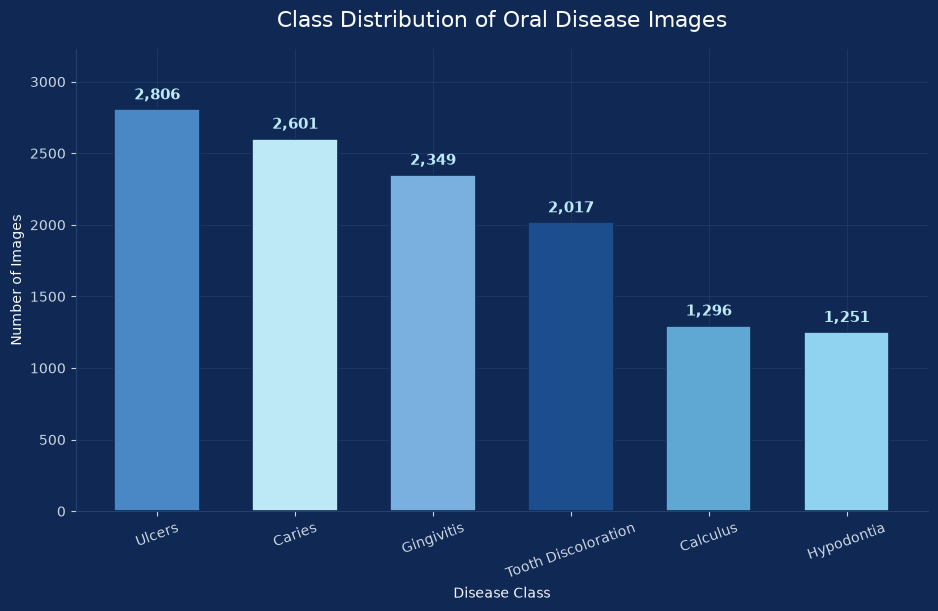

Saved: reports/class_pie.png


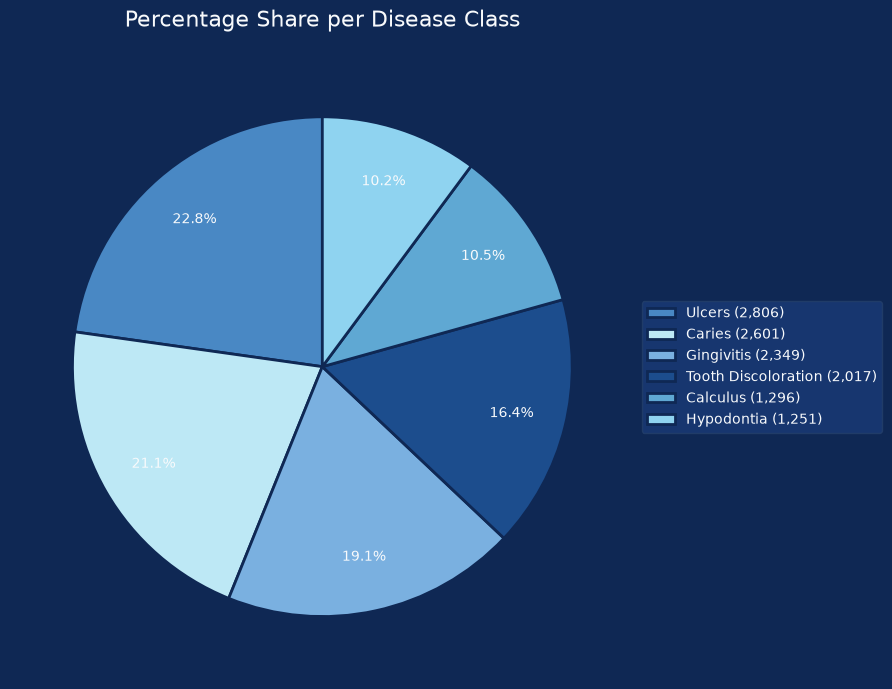


Imbalance ratio (largest / smallest): 2.24:1
Largest  class : Ulcers (2,806)
Smallest class : Hypodontia (1,251)
Saved: reports/sample_images.png


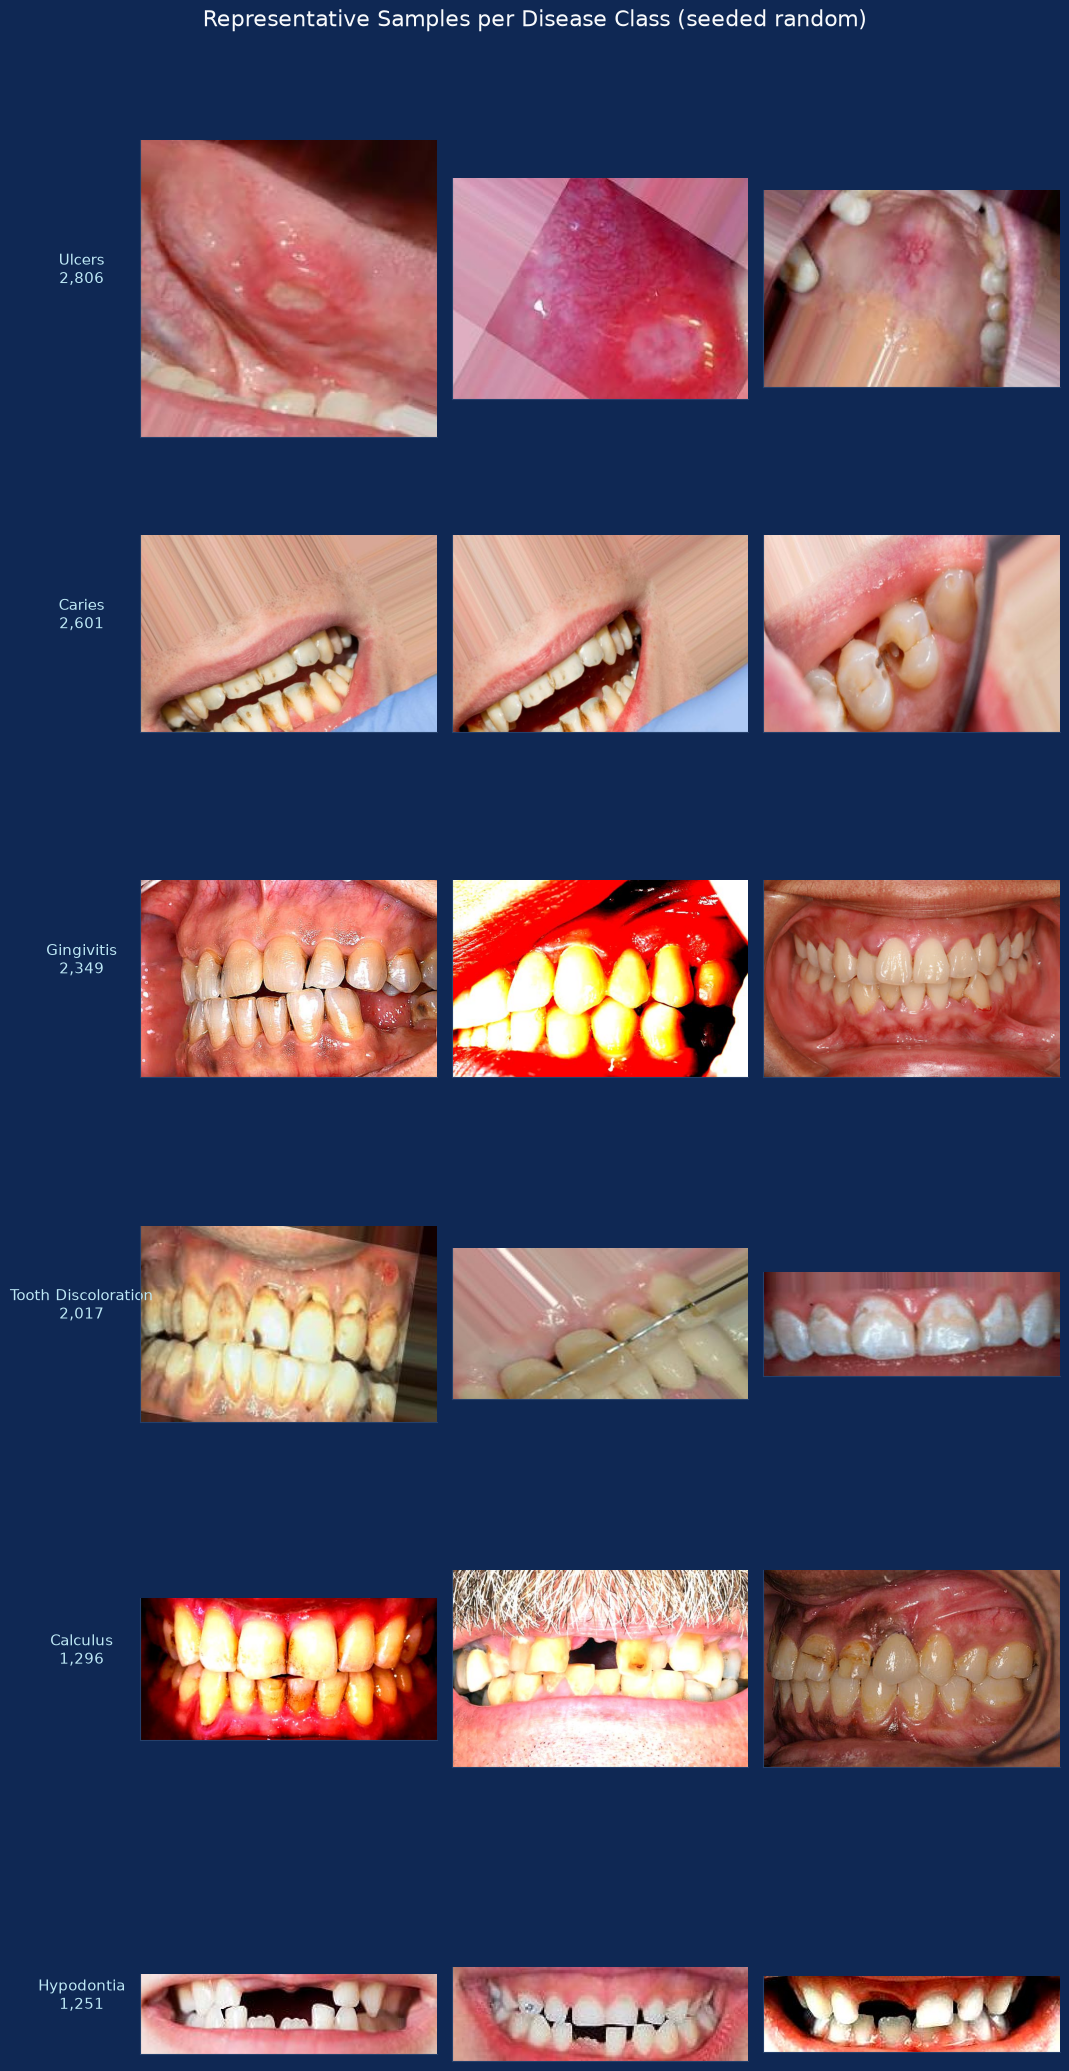


IMAGE DIMENSION SUMMARY
         width   height  aspect_ratio  megapixels
count  600.000  600.000       600.000     600.000
mean   433.190  281.298         1.669       0.141
std    173.116  130.433         0.579       0.102
min    121.000   58.000         0.560       0.009
25%    275.000  180.000         1.500       0.050
50%    379.500  227.500         1.503       0.076
75%    612.000  408.000         1.686       0.250
max    612.000  612.000         5.069       0.370
Saved: reports/resolution_distribution.png


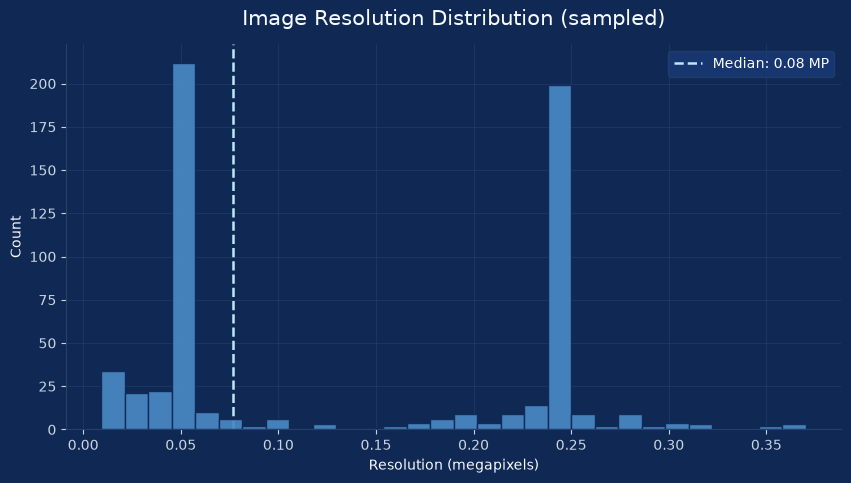

Saved: reports/aspect_ratio_distribution.png


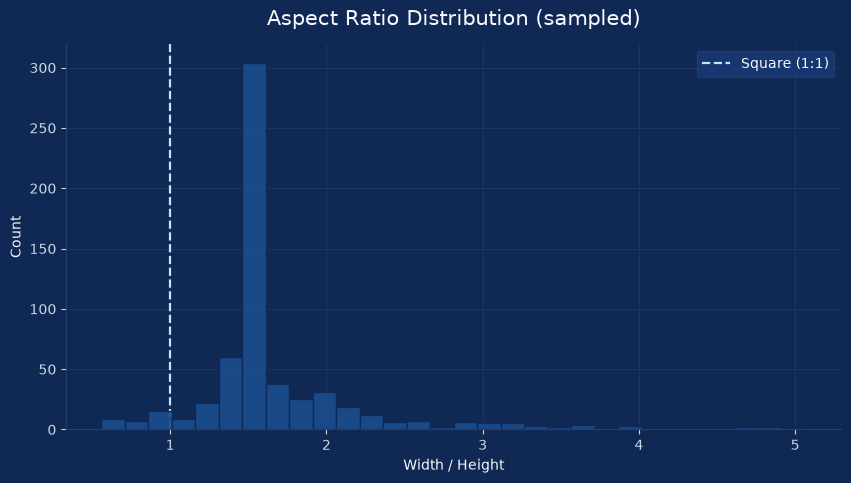

Saved: reports/format_distribution.png


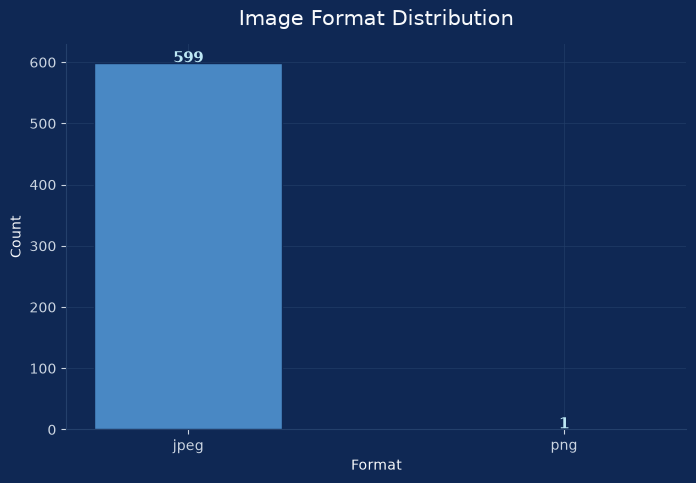

In [3]:
# ============================================================================
# 3. DATASET EXPLORATION
# ============================================================================
classes = summary_df["class"].tolist()
counts = summary_df["total_images"].tolist()

# ---- 3.1 Class distribution (bar chart) ------------------------------------
fig, ax = themed_figure(11, 6)
bars = ax.bar(classes, counts, color=CHART_COLORS[: len(classes)], width=0.62,
              edgecolor=BG, linewidth=1.2, zorder=3)
for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 45,
            f"{cnt:,}", ha="center", va="bottom", fontsize=11,
            fontweight="bold", color=HIGHLIGHT)
ax.set_title("Class Distribution of Oral Disease Images", fontsize=16, pad=16)
ax.set_xlabel("Disease Class")
ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(counts) * 1.15)
ax.tick_params(axis="x", rotation=20)
display_chart(fig, "reports/class_distribution.png")

# ---- 3.2 Percentage share (pie chart) --------------------------------------
fig, ax = themed_figure(9, 9)
counts_arr = np.asarray(counts, dtype=float)
colors = [CHART_COLORS[i] for i in range(len(classes))]
wedges, _, _ = ax.pie(
    counts, labels=None, colors=colors, autopct="%1.1f%%", startangle=90,
    pctdistance=0.78, wedgeprops={"edgecolor": BG, "linewidth": 2},
    textprops={"color": TEXT, "fontsize": 10},
)
ax.legend(wedges, [f"{c} ({n:,})" for c, n in zip(classes, counts)],
          loc="center left", bbox_to_anchor=(1.0, 0.5), frameon=True,
          facecolor=ELEVATED, edgecolor=GRID, labelcolor=TEXT, fontsize=10)
ax.set_title("Percentage Share per Disease Class", fontsize=16, pad=20)
fig.tight_layout()
display_chart(fig, "reports/class_pie.png")

# ---- 3.3 Balance analysis ---------------------------------------------------
min_class = summary_df.loc[summary_df["total_images"].idxmin()]
max_class = summary_df.loc[summary_df["total_images"].idxmax()]
imbalance_ratio = max_class["total_images"] / min_class["total_images"]
print(f"\nImbalance ratio (largest / smallest): {imbalance_ratio:.2f}:1")
print(f"Largest  class : {max_class['class']} ({max_class['total_images']:,})")
print(f"Smallest class : {min_class['class']} ({min_class['total_images']:,})")

# ---- 3.4 Sample images (seeded) --------------------------------------------
rng = np.random.default_rng(42)
SAMPLES_PER_CLASS = 3
classes_sorted = sorted(class_stats, key=lambda k: class_stats[k]["total_images"], reverse=True)

fig, axes = plt.subplots(len(classes_sorted), SAMPLES_PER_CLASS,
                         figsize=(SAMPLES_PER_CLASS * 3.6, len(classes_sorted) * 3.6))
for row_idx, disease in enumerate(classes_sorted):
    class_dir = dataset_root / class_stats[disease]["directory"]
    images = sorted(list_images(class_dir))
    picks = rng.choice(len(images), size=min(SAMPLES_PER_CLASS, len(images)), replace=False)
    for col_idx, img_idx in enumerate(picks):
        ax = axes[row_idx, col_idx]
        img = np.asarray(Image.open(images[img_idx]).convert("RGB"))
        ax.imshow(img)
        ax.set_xticks([])
        ax.set_yticks([])
        if col_idx == 0:
            ax.set_ylabel(f"{disease}\n{class_stats[disease]['total_images']:,}",
                          rotation=0, fontsize=11, color=HIGHLIGHT, labelpad=42)
fig.suptitle("Representative Samples per Disease Class (seeded random)",
             fontsize=16, y=1.02)
fig.tight_layout()
display_chart(fig, "reports/sample_images.png")

# ---- 3.5 Image dimensions, aspect ratio, formats ----------------------------
MAX_SAMPLES = 100


def analyze_dimensions(class_dir: Path, max_samples: int = MAX_SAMPLES) -> list:
    """Collect width, height and format for a sample of images."""
    images = sorted(list_images(class_dir))
    step = max(1, len(images) // max_samples)
    records = []
    for path in images[::step][:max_samples]:
        try:
            with Image.open(path) as img:
                records.append({
                    "class": class_dir.name, "width": img.width, "height": img.height,
                    "format": (img.format or "").lower(), "path": str(path),
                })
        except Exception:
            continue
    return records


dim_records = []
for disease, stats in class_stats.items():
    dim_records.extend(analyze_dimensions(dataset_root / stats["directory"]))

dims_df = pd.DataFrame(dim_records)
dims_df["aspect_ratio"] = dims_df["width"] / dims_df["height"]
dims_df["megapixels"] = dims_df["width"] * dims_df["height"] / 1e6

print("\nIMAGE DIMENSION SUMMARY")
print(dims_df[["width", "height", "aspect_ratio", "megapixels"]]
      .describe().round(3).to_string())

# Resolution histogram
fig, ax = themed_figure(10, 5)
ax.hist(dims_df["megapixels"], bins=30, color=SECONDARY, edgecolor=BG,
        alpha=0.92, zorder=3)
ax.axvline(dims_df["megapixels"].median(), color=HIGHLIGHT, linestyle="--",
           linewidth=1.8, label=f"Median: {dims_df['megapixels'].median():.2f} MP")
ax.set_title("Image Resolution Distribution (sampled)", fontsize=15, pad=14)
ax.set_xlabel("Resolution (megapixels)")
ax.set_ylabel("Count")
ax.legend(frameon=True, facecolor=ELEVATED, edgecolor=GRID, labelcolor=TEXT)
display_chart(fig, "reports/resolution_distribution.png")

# Aspect ratio histogram
fig, ax = themed_figure(10, 5)
ax.hist(dims_df["aspect_ratio"], bins=30, color=ACCENT, edgecolor=BG,
        alpha=0.92, zorder=3)
ax.axvline(1.0, color=HIGHLIGHT, linestyle="--", linewidth=1.6, label="Square (1:1)")
ax.set_title("Aspect Ratio Distribution (sampled)", fontsize=15, pad=14)
ax.set_xlabel("Width / Height")
ax.set_ylabel("Count")
ax.legend(frameon=True, facecolor=ELEVATED, edgecolor=GRID, labelcolor=TEXT)
display_chart(fig, "reports/aspect_ratio_distribution.png")

# Format distribution
fmt_counts = dims_df["format"].value_counts()
fig, ax = themed_figure(8, 5)
bars = ax.bar(fmt_counts.index, fmt_counts.values, color=CHART_COLORS,
              width=0.5, edgecolor=BG, zorder=3)
for bar, v in zip(bars, fmt_counts.values):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 1,
            str(v), ha="center", fontsize=11, fontweight="bold", color=HIGHLIGHT)
ax.set_title("Image Format Distribution", fontsize=15, pad=14)
ax.set_xlabel("Format")
ax.set_ylabel("Count")
display_chart(fig, "reports/format_distribution.png")


<a id="sec-quality"></a>

## 4 &middot; Data Quality Assessment<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Checks performed

| Check | Method |
| --- | --- |
| Corrupted / unreadable images | <code>PIL Image.verify()</code> on 150-image sample per class |
| Duplicate filenames | Full filename scan (within-class vs cross-class) |
| Unsupported formats | Full recursive scan of class folders |
| Empty folders | Recursive directory scan |
| Label consistency | Folder-to-class mapping audit |

<div class="box key">A machine-readable <b>Data Quality Report</b> is saved to <code>reports/quality_report.json</code>.</div>


In [4]:
# ============================================================================
# 4. DATA QUALITY ASSESSMENT
# ============================================================================
quality_report = {}


def check_images_readable(class_dir: Path, limit: int = 150) -> list:
    """Try to open a sample of images; return failures."""
    images = sorted(list_images(class_dir))
    step = max(1, len(images) // limit)
    broken = []
    for path in images[::step][:limit]:
        try:
            with Image.open(path) as img:
                img.verify()
        except Exception as exc:
            broken.append({"file": path.name, "error": str(exc)})
    return broken


def check_duplicate_filenames() -> dict:
    """Classify filename collisions: within-class (real risk) vs cross-class."""
    name_classes: dict = {}
    within_count = 0
    for disease, stats in class_stats.items():
        names = [p.name.lower() for p in list_images(dataset_root / stats["directory"])]
        repeated = {n for n, cnt in Counter(names).items() if cnt > 1}
        within_count += len(repeated)
        for n in set(names):
            name_classes.setdefault(n, set()).add(disease)
    cross = {n: c for n, c in name_classes.items() if len(c) > 1}
    return {"within_class": within_count, "cross_class": len(cross)}


def check_unsupported_files(dataset_root: Path) -> list:
    """List non-image files inside class folders."""
    unsupported = []
    for disease, stats in class_stats.items():
        class_dir = dataset_root / stats["directory"]
        for p in class_dir.rglob("*"):
            if p.is_file() and p.suffix.lower() not in IMG_EXTENSIONS:
                unsupported.append(str(p.relative_to(dataset_root)))
    return unsupported


def check_empty_folders(dataset_root: Path) -> list:
    """Find directories that contain no image files."""
    empty = []
    for d in sorted(dataset_root.rglob("*")):
        if d.is_dir() and not list_images(d):
            empty.append(str(d.relative_to(dataset_root)))
    return empty


# 4.1 Corrupted / unreadable images
broken_by_class = {}
for disease, stats in class_stats.items():
    broken = check_images_readable(dataset_root / stats["directory"])
    broken_by_class[disease] = broken
    quality_report.setdefault("corrupted_images", {})[disease] = len(broken)
print("Corrupted / unreadable image check (sample of 150 per class):")
for disease, broken in broken_by_class.items():
    status = "OK" if not broken else f"{len(broken)} FAILURES"
    print(f"  {disease:<22} {status}")

# 4.2 Duplicate filenames
dup_check = check_duplicate_filenames()
quality_report["duplicate_filenames"] = {
    "within_class": dup_check["within_class"],
    "cross_class_collisions": dup_check["cross_class"],
}
print(f"\nDuplicate filenames within a class (real risk): {dup_check['within_class']}")
print(f"Cross-class filename collisions (benign, Kaggle naming): {dup_check['cross_class']}")

# 4.3 Unsupported formats
unsupported = check_unsupported_files(dataset_root)
quality_report["unsupported_files"] = unsupported
print(f"\nUnsupported / non-image files in class folders: {len(unsupported)}")

# 4.4 Empty folders
empty_folders = check_empty_folders(dataset_root)
quality_report["empty_folders"] = empty_folders
print(f"Empty folders (no images): {len(empty_folders)}")

# 4.5 Label consistency
quality_report["label_notes"] = [
    "6 classes with consistent folder-to-label mapping.",
    "Mixed YOLO-annotated folder excluded from training (noisy labels).",
]

Path("reports").mkdir(exist_ok=True)
Path("reports/quality_report.json").write_text(
    json.dumps(quality_report, indent=2), encoding="utf-8"
)
print("\nSaved: reports/quality_report.json")


Corrupted / unreadable image check (sample of 150 per class):
  Calculus               OK
  Caries                 OK
  Gingivitis             OK
  Ulcers                 OK
  Tooth Discoloration    OK
  Hypodontia             OK

Duplicate filenames within a class (real risk): 0
Cross-class filename collisions (benign, Kaggle naming): 1515

Unsupported / non-image files in class folders: 0
Empty folders (no images): 3

Saved: reports/quality_report.json


<a id="sec-stats"></a>

## 5 &middot; Statistical Summary<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

The dataset is summarized with descriptive statistics: totals, per-class counts, mean,
median, standard deviation, and minimum / maximum class sizes. The **inverse-frequency
class weights** <code>w = N / (C * n_c)</code> are computed to guide Milestone 3 training.


PER-CLASS IMAGE COUNTS
              class  total_images
             Ulcers          2806
             Caries          2601
         Gingivitis          2349
Tooth Discoloration          2017
           Calculus          1296
         Hypodontia          1251

DESCRIPTIVE STATISTICS
             Metric  Value
       Total images  12320
  Number of classes      6
  Mean images/class 2053.3
Median images/class   2183
            Std dev  659.2
     Min class size   1251
     Max class size   2806

Saved: reports/class_statistics.csv

COMPUTED CLASS WEIGHTS (inverse frequency, normalized)
              class  total_images  class_weight
             Ulcers          2806      0.731765
             Caries          2601      0.789440
         Gingivitis          2349      0.874131
Tooth Discoloration          2017      1.018014
           Calculus          1296      1.584362
         Hypodontia          1251      1.641354
Saved: reports/class_weights.png


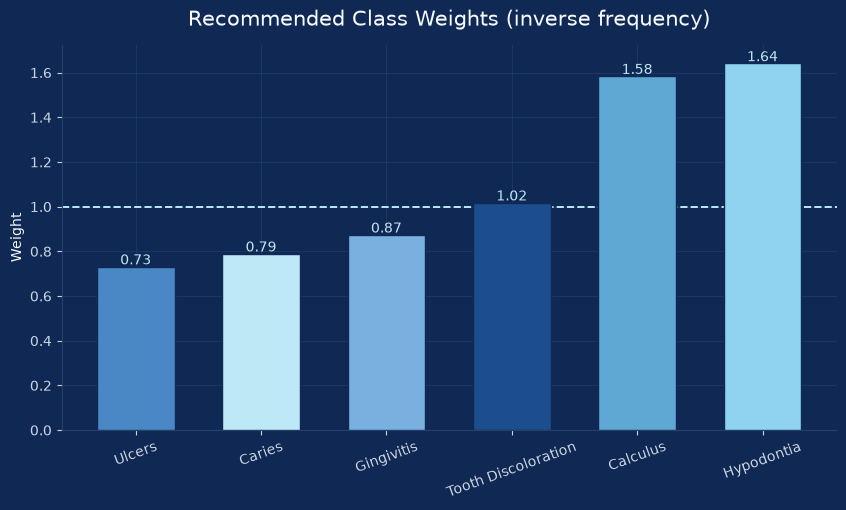


Saved: reports/analysis_summary.json


In [5]:
# ============================================================================
# 5. STATISTICAL SUMMARY
# ============================================================================
stats_table = summary_df[["class", "total_images"]].copy()
counts_all = stats_table["total_images"]
stats_summary = pd.DataFrame({
    "Metric": ["Total images", "Number of classes", "Mean images/class",
               "Median images/class", "Std dev", "Min class size", "Max class size"],
    "Value": [total_images, len(stats_table), f"{counts_all.mean():.1f}",
              f"{counts_all.median():.0f}", f"{counts_all.std():.1f}",
              int(counts_all.min()), int(counts_all.max())],
})
print("PER-CLASS IMAGE COUNTS")
print(stats_table.to_string(index=False))
print("\nDESCRIPTIVE STATISTICS")
print(stats_summary.to_string(index=False))

stats_table.to_csv("reports/class_statistics.csv", index=False)
print("\nSaved: reports/class_statistics.csv")

# ---- Class imbalance analysis + weights -------------------------------------
n_classes = len(summary_df)
class_weights = {}
for _, row in summary_df.iterrows():
    class_weights[row["class"]] = total_images / (n_classes * row["total_images"])

summary_df["class_weight"] = summary_df["class"].map(class_weights)
print("\nCOMPUTED CLASS WEIGHTS (inverse frequency, normalized)")
print(summary_df[["class", "total_images", "class_weight"]].to_string(index=False))

fig, ax = themed_figure(10, 5)
weights = [class_weights[c] for c in classes]
bars = ax.bar(classes, weights, color=CHART_COLORS[: len(classes)], width=0.62,
              edgecolor=BG, zorder=3)
for bar, w in zip(bars, weights):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.01,
            f"{w:.2f}", ha="center", fontsize=10, color=HIGHLIGHT)
ax.axhline(1.0, color=HIGHLIGHT, linestyle="--", linewidth=1.4)
ax.set_title("Recommended Class Weights (inverse frequency)", fontsize=15, pad=14)
ax.set_ylabel("Weight")
ax.tick_params(axis="x", rotation=20)
display_chart(fig, "reports/class_weights.png")

# ---- Machine-readable summary for downstream notebooks ----------------------
findings = {
    "total_images": total_images,
    "classes": n_classes,
    "imbalance_ratio": round(imbalance_ratio, 2),
    "split": {"train": 0.70, "val": 0.15, "test": 0.15},
    "per_class": summary_df[["class", "total_images"]].to_dict("records"),
    "dataset_root": str(dataset_root),
}
Path("reports/analysis_summary.json").write_text(
    json.dumps(findings, indent=2), encoding="utf-8"
)
print("\nSaved: reports/analysis_summary.json")


<a id="sec-insights"></a>

## 6 &middot; Insights<div style="height:3px;border-radius:2px;background:linear-gradient(90deg,#1C4D8D,#4988C4,#BDE8F5);margin:20px 0;"></div>

### Strengths

- Clean 6-class folder structure with 12,320 images
- Consistent RGB photographs of the oral cavity
- No corrupted images or unsupported files detected in the audit

### Weaknesses &amp; Risks

- Moderate class imbalance (2.24:1) - Hypodontia and Calculus are minority classes
- Variable resolution and aspect ratio require standardization
- Cross-class filename collisions (benign) complicate naive merging

### Expected Preprocessing Challenges

- Resizing and aspect-ratio normalization to 224x224
- Pixel-range normalization per the EfficientNet preprocessing contract
- Balanced batching given the imbalance ratio

### Recommendations for the Next Phase

| Priority | Action |
| --- | --- |
| High | Stratified 70/15/15 split preserving class proportions |
| High | Inverse-frequency class weights during training |
| Medium | Mild augmentation (rotation, flip, zoom, brightness) on training only |
| Medium | EfficientNet preprocessing pipeline (RGB, per-channel normalization) |

<div style="border-top:1px solid #24406B;margin-top:24px;padding-top:12px;color:#CBD5E1;font-size:12px;">
<b>AI-Powered Oral Disease Detection System</b> &middot; Milestone 1 / 5 &middot; Next: <code>02_Preprocessing.ipynb</code> &middot; Design: Modern Medical AI
</div>
